# Strategy Evaluator Notebook

<div dir="rtl" style="text-align: right;">

اين نوت بوک براي ارزيابي Strategy شما دانشجويان فراهم شده است.

شما فقط باید strategy خودتان را در سلول `Student Strategy Input` قرار بدهيد. سپس نوت‌بوک همان strategy را هم روی train/reference dataset و هم روی evaluation/test dataset اجرا می‌کند.

</div>


In [12]:
import pandas as pd
import numpy as np
import random
import warnings
import matplotlib.pyplot as plt
import os
import json
from datetime import datetime

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# =========================================================
# Evaluator Dataset Paths
# =========================================================

# The reference file is used only to infer the exact feature list and fuzzy modes.
# For best consistency with the optimizer notebook, keep this as the same train file
# that was used when the strategy was created.
REFERENCE_SCHEMA_PATH = "data/uploads/train-v2.csv"

# The evaluation file is the dataset on which the student's strategy is tested.
EVALUATION_FILE_PATH = "data/uploads/test-v2.csv"

# Optional output folder for evaluation results.
# Train and test outputs are saved in separate subfolders to avoid overwriting files.
EVALUATION_OUTPUT_DIR = "student_strategy_evaluation"

# =========================================================
# Shared Trading Constants - keep aligned with v18 optimizer
# =========================================================

# Total round-trip trading fee percent, including entry and exit costs.
# Example: 0.20 means total fees for opening and closing a trade are 0.20% of notional.
FEE_PCT = 0.20
MAX_HOLD_CANDLES = 288

# Default trading side. A strategy can override this using its own "direction" field.
# Valid values: "long" or "short".
TRADE_DIRECTION = "long"



In [2]:
# =========================================================
# Trade Sizing and Capital Settings
# =========================================================

INITIAL_CAPITAL = 1000.0        # Starting account equity
LEVERAGE = 1.0                  # 1.0 = no leverage

# ------------------------------------------------------------------
# Portfolio Exposure Management
# ------------------------------------------------------------------
# The active safety rule is capital availability: total open notional exposure
# must stay within available equity * leverage.
#
# Because the current dataset does not include exact exit_bar_index,
# every opened position reserves exposure until MAX_HOLD_CANDLES.
# PnL is realized when that conservative release point is reached.
# ------------------------------------------------------------------

# Maximum total notional exposure across all open positions.
# Example: 100 means total open notional <= current equity * leverage.
MAX_TOTAL_EXPOSURE_PCT = 100.0

# Minimum allowed dollar notional for each trade.
# This is only a dust-trade filter; sizing is controlled by the strategy's capital_pct.
MIN_POSITION_NOTIONAL = 1.0



In [3]:
# =========================================================
# Utilities
# =========================================================

def detect_feature_mode(series):
    unique_vals = series.dropna().unique()
    n_unique = len(unique_vals)

    if n_unique <= 2 and set(unique_vals).issubset({0, 1}):
        return "binary"

    if n_unique <= 3 and set(unique_vals).issubset({-1, 0, 1}):
        return "ternary"

    zero_ratio = (series == 0).mean()

    if series.min() < 0:
        return "sparse_signed" if zero_ratio > 0.3 else "signed"

    return "sparse_positive" if zero_ratio > 0.3 else "positive"


def safe_profit_factor(gross_wins, gross_losses):
    if gross_losses <= 0 and gross_wins > 0:
        return 99.0

    if gross_losses <= 0:
        return 0.0

    return gross_wins / gross_losses


def normalize_direction(direction):
    """Normalize and validate trade direction."""
    direction = "long" if direction is None else str(direction).strip().lower()

    if direction not in {"long", "short"}:
        raise ValueError("TRADE_DIRECTION must be either 'long' or 'short'.")

    return direction


def decode_gene_value(gene, info):
    mode = info["mode"]

    if mode == "binary":
        return "Active (1)" if gene == 1 else "Inactive (0)"

    if mode == "ternary":
        return ["Negative (-1)", "Neutral (0)", "Positive (1)"][gene]

    if mode == "positive":
        return ["Very Low", "Low", "Medium", "High", "Very High"][gene]

    if mode == "sparse_signed":
        return [
            "Strong Negative",
            "Weak Negative",
            "Exactly Zero",
            "Weak Positive",
            "Strong Positive",
        ][gene]

    return [
        "Extreme Bearish",
        "Strong Bearish",
        "Bearish",
        "Weak Bearish",
        "Neutral Negative",
        "Neutral Positive",
        "Weak Bullish",
        "Bullish",
        "Strong Bullish",
        "Extreme Bullish",
    ][gene]


def decode_rule(rule, fuzzy_engine):
    conditions = []

    for idx, gene in enumerate(rule):
        info = fuzzy_engine.feature_info[idx]

        if gene == info["dont_care"]:
            continue

        value_text = decode_gene_value(gene, info)
        conditions.append(f"[{info['col']}] IS {value_text}")

    return conditions



In [4]:
# =========================================================
# Data Loading
# =========================================================

def load_reference_dataset_schema(path):
    print("Loading reference schema data...")
    data = pd.read_csv(path)

    if "datetime" in data.columns:
        data["datetime"] = pd.to_datetime(data["datetime"], errors="coerce", utc=True)
        data["datetime"] = data["datetime"].dt.tz_localize(None)

    if "datetime" in data.columns and "symbol" in data.columns:
        data = data.sort_values(["datetime", "symbol"]).reset_index(drop=True)
    elif "datetime" in data.columns:
        data = data.sort_values("datetime").reset_index(drop=True)
    elif "symbol" in data.columns:
        data = data.sort_values("symbol").reset_index(drop=True)

    if "symbol" in data.columns:
        data["_symbol_bar_index"] = data.groupby("symbol").cumcount()
    else:
        data["_symbol_bar_index"] = np.arange(len(data))

    label_columns = [
        "label_open_next",
        "label_close_288",
        "label_min_288",
        "label_max_288",
        "label_max_before_min",
    ]

    missing_labels = [c for c in label_columns if c not in data.columns]
    if missing_labels:
        raise ValueError(f"Missing required label columns: {missing_labels}")

    meta_columns = [
        "datetime",
        "symbol",
        "dataset_type",
        "_symbol_bar_index",
    ]

    features = [c for c in data.columns if c not in label_columns + meta_columns]

    data = data.dropna(subset=label_columns).reset_index(drop=True)
    data[features] = data[features].fillna(0)

    if "symbol" in data.columns:
        data["_symbol_bar_index"] = data.groupby("symbol").cumcount()
    else:
        data["_symbol_bar_index"] = np.arange(len(data))

    modes = {col: detect_feature_mode(data[col]) for col in features}

    print(
        f"Data Loaded and Cleaned: {data.shape[0]} valid rows | Features: {len(features)}"
    )

    return data, features, modes, label_columns


def load_and_prepare_dataset_for_evaluation(file_path, feature_cols, label_cols):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Dataset file not found: {file_path}")

    try:
        df_eval = pd.read_csv(file_path)
        if len(df_eval.columns) < 5:
            df_eval = pd.read_csv(file_path, sep="\t")
    except Exception:
        df_eval = pd.read_csv(file_path, sep="\t")

    df_eval.columns = [str(c).strip() for c in df_eval.columns]

    missing_labels = [c for c in label_cols if c not in df_eval.columns]
    if missing_labels:
        raise ValueError(f"Missing label columns in {file_path}: {missing_labels}")

    missing_features = [c for c in feature_cols if c not in df_eval.columns]
    if missing_features:
        raise ValueError(f"Missing feature columns in {file_path}: {missing_features}")

    if "datetime" in df_eval.columns:
        df_eval["datetime"] = pd.to_datetime(
            df_eval["datetime"],
            errors="coerce",
            utc=True,
        )
        df_eval["datetime"] = df_eval["datetime"].dt.tz_localize(None)

    if "datetime" in df_eval.columns and "symbol" in df_eval.columns:
        df_eval = df_eval.sort_values(["datetime", "symbol"]).reset_index(drop=True)
    elif "datetime" in df_eval.columns:
        df_eval = df_eval.sort_values("datetime").reset_index(drop=True)
    elif "symbol" in df_eval.columns:
        df_eval = df_eval.sort_values("symbol").reset_index(drop=True)

    df_eval = df_eval.dropna(subset=label_cols).reset_index(drop=True)
    df_eval[feature_cols] = df_eval[feature_cols].fillna(0)

    if "symbol" in df_eval.columns:
        df_eval["_symbol_bar_index"] = df_eval.groupby("symbol").cumcount()
    else:
        df_eval["_symbol_bar_index"] = np.arange(len(df_eval))

    return df_eval






def load_training_and_evaluation_data(reference_schema_path, evaluation_file_path):
    """
    Load the reference training dataset and the evaluation dataset.

    The training dataset is used for two purposes:
    1. It provides the exact feature list and feature_modes used by the optimizer.
    2. It is also evaluated so students can compare train vs test performance.

    Important:
    This evaluator intentionally does NOT infer feature modes from the evaluation
    dataset. The optimizer created the exported strategy using train-v2.csv, so the
    evaluator must keep the train-side schema for both train and test evaluation.
    """
    if not os.path.exists(reference_schema_path):
        raise FileNotFoundError(
            "Reference schema/train file was not found. "
            "Set REFERENCE_SCHEMA_PATH to the same train-v2.csv file that was used "
            "when the strategy was generated. The evaluator will not infer fuzzy "
            "modes from the test/evaluation file because that can change feature "
            "modes and break strategy behavior."
        )

    df_train, feature_cols, feature_modes, label_cols = load_reference_dataset_schema(
        reference_schema_path
    )
    print(f"Reference/train source: {reference_schema_path}")
    print(f"Train data ready: {df_train.shape[0]} rows | Features: {len(feature_cols)}")

    df_eval = load_and_prepare_dataset_for_evaluation(
        file_path=evaluation_file_path,
        feature_cols=feature_cols,
        label_cols=label_cols,
    )

    print(f"Evaluation/test data loaded: {df_eval.shape[0]} rows | Features: {len(feature_cols)}")
    return df_train, df_eval, feature_cols, feature_modes, label_cols


def load_schema_and_evaluation_data(reference_schema_path, evaluation_file_path):
    """
    Backward-compatible wrapper for older evaluator cells.

    Returns only the evaluation dataset plus schema information, exactly like the
    previous version. New cells should use load_training_and_evaluation_data().
    """
    _df_train, df_eval, feature_cols, feature_modes, label_cols = load_training_and_evaluation_data(
        reference_schema_path=reference_schema_path,
        evaluation_file_path=evaluation_file_path,
    )
    return df_eval, feature_cols, feature_modes, label_cols



In [5]:
# =========================================================
# Adaptive Fuzzy Engine
# =========================================================

class AdaptiveFuzzyEngine:
    def __init__(self, df, feature_cols, feature_modes):
        self.feature_cols = feature_cols
        self.num_features = len(feature_cols)
        self.feature_info = []
        self.data_matrix = np.zeros((len(df), self.num_features), dtype=np.int8)

        for idx, col in enumerate(feature_cols):
            mode = feature_modes[col]
            series = df[col].values

            if mode == "binary":
                self.data_matrix[:, idx] = np.nan_to_num(series, nan=0).astype(np.int8)
                self.feature_info.append(
                    {"col": col, "mode": mode, "num_classes": 2, "dont_care": 2}
                )

            elif mode == "ternary":
                self.data_matrix[:, idx] = (np.nan_to_num(series, nan=0) + 1).astype(
                    np.int8
                )
                self.feature_info.append(
                    {"col": col, "mode": mode, "num_classes": 3, "dont_care": 3}
                )

            elif mode == "positive":
                bins = [-np.inf, 0.2, 0.4, 0.6, 0.8, np.inf]
                disc = pd.cut(series, bins=bins, labels=False)
                self.data_matrix[:, idx] = np.nan_to_num(disc, nan=5).astype(np.int8)
                self.feature_info.append(
                    {"col": col, "mode": mode, "num_classes": 5, "dont_care": 5}
                )

            elif mode == "sparse_signed":
                bins = [-np.inf, -0.25, -1e-5, 1e-5, 0.25, np.inf]
                disc = pd.cut(series, bins=bins, labels=False)
                self.data_matrix[:, idx] = np.nan_to_num(disc, nan=5).astype(np.int8)
                self.feature_info.append(
                    {"col": col, "mode": mode, "num_classes": 5, "dont_care": 5}
                )

            else:
                bins = [
                    -np.inf,
                    -0.8,
                    -0.6,
                    -0.4,
                    -0.2,
                    0.0,
                    0.2,
                    0.4,
                    0.6,
                    0.8,
                    np.inf,
                ]
                disc = pd.cut(series, bins=bins, labels=False)
                self.data_matrix[:, idx] = np.nan_to_num(disc, nan=10).astype(np.int8)
                self.feature_info.append(
                    {"col": col, "mode": mode, "num_classes": 10, "dont_care": 10}
                )





In [6]:
# =========================================================
# Rule-Set Signal / Entry Builders
# =========================================================

def _get_rule_array_from_entry(rule_entry):
    """
    Extract the numpy rule array from a current per-rule TP/SL rule entry.
    """
    if not isinstance(rule_entry, dict):
        raise ValueError(
            "Each rule entry must be a dict with keys: 'rule', 'tp', and 'sl'."
        )
    return rule_entry.get("rule")


def build_rule_set_entries(data_matrix, rule_set, dont_cares):
    """
    Build trade entries with per-rule TP/SL.

    Output is a chronological list of dictionaries:
        {
            "idx": row_index,
            "rule_index": 1-based rule index,
            "tp": rule-specific TP,
            "sl": rule-specific SL,
            "capital_pct": rule-specific capital allocation percent
        }

    Important:
    If multiple rules trigger on the same row, the first matching rule in the
    rule_set has priority. This prevents opening duplicate entries on the same
    symbol/time just because multiple rules matched the same candle.

    Student evaluator note:
    Exported student strategies are text conditions. The original project logic
    evaluates those text conditions directly with threshold rules. Therefore this
    builder also accepts precomputed `signal_mask` entries so the evaluator does
    not incorrectly re-interpret text labels through detected feature modes.
    """
    if not rule_set:
        return []

    n_rows = data_matrix.shape[0]
    assigned_mask = np.zeros(n_rows, dtype=bool)
    entries = []

    for rule_idx, rule_or_entry in enumerate(rule_set, start=1):
        if not isinstance(rule_or_entry, dict):
            raise ValueError("Each rule entry must be a dictionary.")

        tp = float(rule_or_entry["tp"])
        sl = float(rule_or_entry["sl"])
        capital_pct = float(rule_or_entry["capital_pct"])

        if not np.isfinite(capital_pct) or capital_pct <= 0:
            raise ValueError(
                f"Rule {rule_idx} has invalid capital_pct: {capital_pct}"
            )

        if "signal_mask" in rule_or_entry:
            rule_signals = np.asarray(rule_or_entry["signal_mask"], dtype=bool)
            if len(rule_signals) != data_matrix.shape[0]:
                raise ValueError(
                    f"Rule {rule_idx} signal_mask length does not match dataset length."
                )
        else:
            rule = _get_rule_array_from_entry(rule_or_entry)
            if rule is None:
                continue

            active_mask = rule != dont_cares
            active_idx = np.where(active_mask)[0]

            if len(active_idx) == 0:
                continue

            rule_signals = np.all(
                data_matrix[:, active_idx] == rule[active_idx],
                axis=1,
            )

        new_match_mask = rule_signals & (~assigned_mask)
        matched_indices = np.flatnonzero(new_match_mask)
        if len(matched_indices) == 0:
            continue

        assigned_mask[matched_indices] = True

        for idx in matched_indices:
            entries.append(
                {
                    "idx": int(idx),
                    "rule_index": int(rule_idx),
                    "tp": tp,
                    "sl": sl,
                    "capital_pct": capital_pct,
                }
            )

    entries.sort(key=lambda x: x["idx"])
    return entries



In [7]:
# =========================================================
# Capital-Managed Trade Simulator with Portfolio Exposure Control
# =========================================================

class CapitalManagedTradeSimulator:
    def __init__(
        self,
        df,
        fuzzy_engine,
        trade_direction=TRADE_DIRECTION,
        fee_pct=FEE_PCT,
        initial_capital=INITIAL_CAPITAL,
        leverage=LEVERAGE,
        max_hold_candles=MAX_HOLD_CANDLES,
        max_total_exposure_pct=MAX_TOTAL_EXPOSURE_PCT,
        min_position_notional=MIN_POSITION_NOTIONAL,
    ):
        self.df = df
        self.data_matrix = fuzzy_engine.data_matrix
        self.dont_cares = np.array(
            [info["dont_care"] for info in fuzzy_engine.feature_info]
        )
        self.trade_direction = normalize_direction(trade_direction)

        # fee_pct is treated as the total round-trip fee percent.
        # It must include both entry and exit costs.
        self.fee_pct = float(fee_pct)
        self.round_trip_fee_pct = self.fee_pct
        self.round_trip_fee_rate = self.round_trip_fee_pct / 100.0
        self.fee_rate = self.round_trip_fee_rate

        self.initial_capital = float(initial_capital)
        self.leverage = float(leverage)

        self.max_hold_candles = int(max_hold_candles)

        self.max_total_exposure_pct = float(max_total_exposure_pct)
        self.max_total_exposure_rate = self.max_total_exposure_pct / 100.0
        self.min_position_notional = float(min_position_notional)

        entry = df["label_open_next"].values.astype(float)

        invalid_entry_mask = (~np.isfinite(entry)) | (entry <= 0)
        if np.any(invalid_entry_mask):
            bad_count = int(np.sum(invalid_entry_mask))
            raise ValueError(
                "Invalid label_open_next values found. "
                f"All entry prices must be finite and positive. Bad rows: {bad_count}"
            )

        valid_entry = entry
        self.entry_price = valid_entry

        self.max_ret = (df["label_max_288"].values - valid_entry) / valid_entry * 100.0
        self.min_ret = (df["label_min_288"].values - valid_entry) / valid_entry * 100.0
        self.close_ret = (
            (df["label_close_288"].values - valid_entry) / valid_entry * 100.0
        )

        self.max_before_min = df["label_max_before_min"].values

        if "symbol" in df.columns:
            self.symbols = df["symbol"].astype(str).values
        else:
            self.symbols = np.array(["UNKNOWN"] * len(df))

        if "_symbol_bar_index" in df.columns:
            self.symbol_bar_index = df["_symbol_bar_index"].values.astype(int)
        else:
            self.symbol_bar_index = np.arange(len(df))

        if "datetime" in df.columns:
            self.datetimes = df["datetime"].values
        else:
            self.datetimes = np.arange(len(df))

        self.release_index = self._precompute_release_indices()

    def _precompute_release_indices(self):
        """
        Precompute the conservative release row index for every possible entry row.

        Current dataset has no exact exit_bar_index. Therefore each opened trade
        reserves exposure until entry_symbol_bar + MAX_HOLD_CANDLES.
        """
        n = len(self.df)
        release_index = np.full(n, n, dtype=np.int64)

        row_index = np.arange(n, dtype=np.int64)
        symbol_codes, _ = pd.factorize(self.symbols, sort=False)

        for sym_code in np.unique(symbol_codes):
            sym_mask = symbol_codes == sym_code
            rows = row_index[sym_mask]
            bars = self.symbol_bar_index[sym_mask].astype(np.int64, copy=False)

            order = np.argsort(bars, kind="mergesort")
            rows_sorted = rows[order]
            bars_sorted = bars[order]

            target_bars = bars_sorted + self.max_hold_candles
            target_positions = np.searchsorted(bars_sorted, target_bars, side="left")

            valid = target_positions < len(rows_sorted)
            if np.any(valid):
                release_index[rows_sorted[valid]] = rows_sorted[target_positions[valid]]

        return release_index

    def _build_trade_outcomes(self, trade_indices, tp, sl):
        if len(trade_indices) == 0:
            return None

        s_max = self.max_ret[trade_indices]
        s_min = self.min_ret[trade_indices]
        s_close = self.close_ret[trade_indices]
        s_mbm = self.max_before_min[trade_indices]

        direction = normalize_direction(self.trade_direction)

        if direction == "long":
            hit_tp = s_max >= tp
            hit_sl = s_min <= -sl
            both_hit = hit_tp & hit_sl

            # Old label-based TP/SL order logic is intentionally preserved.
            price_return_pct = np.where(
                both_hit,
                np.where(s_mbm == 1, tp, -sl),
                np.where(hit_tp, tp, np.where(hit_sl, -sl, s_close)),
            )

            exit_reason = np.where(
                both_hit,
                np.where(s_mbm == 1, "TP", "SL"),
                np.where(hit_tp, "TP", np.where(hit_sl, "SL", "Time_288")),
            )
        else:
            # Short side:
            # TP is reached when price moves down by tp%.
            # SL is reached when price moves up by sl%.
            # max_before_min == 1 means max came before min, which means SL first for shorts.
            hit_tp = s_min <= -tp
            hit_sl = s_max >= sl
            both_hit = hit_tp & hit_sl

            price_return_pct = np.where(
                both_hit,
                np.where(s_mbm == 1, -sl, tp),
                np.where(hit_tp, tp, np.where(hit_sl, -sl, -s_close)),
            )

            exit_reason = np.where(
                both_hit,
                np.where(s_mbm == 1, "SL", "TP"),
                np.where(hit_tp, "TP", np.where(hit_sl, "SL", "Time_288")),
            )

        return {
            "price_return_pct": price_return_pct.astype(float),
            "exit_reason": exit_reason,
            "hit_tp": hit_tp,
            "hit_sl": hit_sl,
        }

    def _release_due_positions(
        self,
        open_positions,
        current_index,
        equity,
        peak_equity,
        max_drawdown_pct,
        open_total_exposure,
        symbol_exposure,
        return_logs,
        logs,
        stats,
    ):
        """
        Release/close all positions whose conservative release row index is reached.
        PnL is realized on release, not at entry. This avoids using future PnL to size
        new trades before the old trade is considered closed.
        """
        still_open = []

        for pos in open_positions:
            if pos["release_index"] <= current_index:
                equity_before_close = equity
                equity += pos["net_pnl"]

                peak_equity = max(peak_equity, equity)
                drawdown_pct = (
                    (peak_equity - equity) / peak_equity * 100.0
                    if peak_equity > 0
                    else 100.0
                )
                max_drawdown_pct = max(max_drawdown_pct, drawdown_pct)

                if pos["net_pnl"] > 0:
                    stats["wins"] += 1
                    stats["gross_profit_sum"] += pos["net_pnl"]
                elif pos["net_pnl"] < 0:
                    stats["loss_count"] += 1
                    stats["gross_loss_sum"] += abs(pos["net_pnl"])

                if pos["exit_reason"] == "Time_288":
                    stats["time_closed_count"] += 1

                account_status = "ACTIVE"
                if equity <= 0:
                    account_status = "ACCOUNT_RUINED"

                if return_logs and pos["log_index"] is not None:
                    log_idx = pos["log_index"]
                    release_idx = pos["release_index"]

                    if release_idx < len(self.datetimes):
                        close_time = self.datetimes[release_idx]
                    else:
                        close_time = self.datetimes[-1] if len(self.datetimes) > 0 else np.nan

                    logs[log_idx].update(
                        {
                            "Release_Index": int(release_idx),
                            "Close_Time": close_time,
                            "Equity_Before_Close": equity_before_close,
                            "Equity_After": equity,
                            "Account_Return_Pct": (
                                equity / self.initial_capital - 1.0
                            )
                            * 100.0,
                            "High_Water_Mark": peak_equity,
                            "Drawdown_Pct": drawdown_pct,
                            "Account_Status": account_status,
                            "Realized": True,
                        }
                    )

                if account_status == "ACCOUNT_RUINED":
                    stats["account_ruined"] = True

                open_total_exposure -= pos["position_notional"]
                sym = pos["symbol"]
                new_sym_exposure = symbol_exposure.get(sym, 0.0) - pos["position_notional"]
                if new_sym_exposure > 0:
                    symbol_exposure[sym] = new_sym_exposure
                elif sym in symbol_exposure:
                    del symbol_exposure[sym]
            else:
                still_open.append(pos)

        return (
            still_open,
            equity,
            peak_equity,
            max_drawdown_pct,
            open_total_exposure,
            symbol_exposure,
            stats,
        )

    def _get_open_exposure(self, open_positions):
        total_exposure = sum(pos["position_notional"] for pos in open_positions)
        symbol_exposure = {}

        for pos in open_positions:
            symbol_exposure[pos["symbol"]] = (
                symbol_exposure.get(pos["symbol"], 0.0) + pos["position_notional"]
            )

        return total_exposure, symbol_exposure

    def _calculate_position_notional(
        self, equity, capital_pct, open_total_exposure, symbol_exposure, symbol
    ):
        """
        Calculate final position notional using:
        1. strategy-defined capital allocation per trade
        2. remaining total portfolio exposure capacity
        """
        capital_pct = float(capital_pct)
        capital_rate = capital_pct / 100.0
        target_position_notional = equity * capital_rate * self.leverage

        max_total_exposure = equity * self.max_total_exposure_rate * self.leverage
        remaining_total_capacity = max(0.0, max_total_exposure - open_total_exposure)
        current_symbol_exposure = symbol_exposure.get(symbol, 0.0)

        position_notional = min(
            target_position_notional,
            remaining_total_capacity,
        )

        sizing_info = {
            "capital_pct": capital_pct,
            "round_trip_fee_rate": self.round_trip_fee_rate,
            "target_position_notional": target_position_notional,
            "open_total_exposure_before": open_total_exposure,
            "open_symbol_exposure_before": current_symbol_exposure,
            "remaining_total_capacity": remaining_total_capacity,
            "final_position_notional": position_notional,
        }

        return position_notional, sizing_info

    def _build_trade_outcome_single(self, idx, tp, sl):
        s_max = self.max_ret[idx]
        s_min = self.min_ret[idx]
        s_close = self.close_ret[idx]
        s_mbm = self.max_before_min[idx]

        direction = self.trade_direction
        if direction == "long":
            hit_tp = s_max >= tp
            hit_sl = s_min <= -sl
            both_hit = hit_tp and hit_sl
            if both_hit:
                if s_mbm == 1:
                    return float(tp), "TP"
                return float(-sl), "SL"
            if hit_tp:
                return float(tp), "TP"
            if hit_sl:
                return float(-sl), "SL"
            return float(s_close), "Time_288"

        hit_tp = s_min <= -tp
        hit_sl = s_max >= sl
        both_hit = hit_tp and hit_sl
        if both_hit:
            if s_mbm == 1:
                return float(-sl), "SL"
            return float(tp), "TP"
        if hit_tp:
            return float(tp), "TP"
        if hit_sl:
            return float(-sl), "SL"
        return float(-s_close), "Time_288"

    def simulate_rule_set(self, rule_set, return_logs=False):
        """
        Simulate a rule set where each rule owns its own TP and SL.

        Expected rule_set format:
            [
                {"rule": np.array(...), "tp": 2.27, "sl": 0.57},
                {"rule": np.array(...), "tp": 2.29, "sl": 0.52},
                ...
            ]

        If more than one rule matches the same row, build_rule_set_entries()
        keeps the first matching rule only.
        """
        entries = build_rule_set_entries(
            data_matrix=self.data_matrix,
            rule_set=rule_set,
            dont_cares=self.dont_cares,
        )

        if len(entries) == 0:
            metrics = {
                "direction": self.trade_direction,
                "total_return_pct": 0.0,
                "max_drawdown_pct": 0.0,
                "win_rate": 0.0,
                "account_ruined": False,
                "loss_count": 0,
                "time_closed_count": 0,
                "raw_signal_count": 0,
                "executed_trades": 0,
                "final_equity": self.initial_capital,
                "profit_factor": 0.0,
                "avg_position_notional": 0.0,
                "skipped_min_notional_count": 0,
                "max_simultaneous_positions": 0,
                "max_total_open_exposure": 0.0,
            }
            return (metrics, pd.DataFrame()) if return_logs else metrics

        equity = self.initial_capital
        peak_equity = self.initial_capital
        max_drawdown_pct = 0.0

        open_positions = []
        logs = []

        stats = {
            "wins": 0,
            "loss_count": 0,
            "time_closed_count": 0,
            "gross_profit_sum": 0.0,
            "gross_loss_sum": 0.0,
            "account_ruined": False,
        }

        executed_trades = 0
        skipped_min_notional_count = 0
        position_notional_sum = 0.0
        max_simultaneous_positions = 0
        max_total_open_exposure = 0.0
        open_total_exposure = 0.0
        symbol_exposure = {}

        for entry in entries:
            idx = int(entry["idx"])
            rule_index = int(entry["rule_index"])
            tp = float(entry["tp"])
            sl = float(entry["sl"])
            capital_pct = float(entry["capital_pct"])

            (
                open_positions,
                equity,
                peak_equity,
                max_drawdown_pct,
                open_total_exposure,
                symbol_exposure,
                stats,
            ) = self._release_due_positions(
                open_positions=open_positions,
                current_index=idx,
                equity=equity,
                peak_equity=peak_equity,
                max_drawdown_pct=max_drawdown_pct,
                open_total_exposure=open_total_exposure,
                symbol_exposure=symbol_exposure,
                return_logs=return_logs,
                logs=logs,
                stats=stats,
            )

            if stats["account_ruined"]:
                break

            symbol = self.symbols[idx]

            position_notional, sizing_info = self._calculate_position_notional(
                equity=equity,
                capital_pct=capital_pct,
                open_total_exposure=open_total_exposure,
                symbol_exposure=symbol_exposure,
                symbol=symbol,
            )

            if position_notional < self.min_position_notional:
                skipped_min_notional_count += 1
                continue

            price_return_pct, exit_reason = self._build_trade_outcome_single(idx, tp, sl)
            price_return_rate = price_return_pct / 100.0

            gross_pnl = position_notional * price_return_rate
            fee = position_notional * self.round_trip_fee_rate
            net_pnl = gross_pnl - fee
            margin_used = position_notional / max(self.leverage, 1e-9)

            release_idx = int(self.release_index[idx])

            log_index = None

            if return_logs:
                log_index = len(logs)
                logs.append(
                    {
                        "Trade_Number": executed_trades + 1,
                        "Direction": self.trade_direction,
                        "Rule_Index": rule_index,
                        "Rule_TP": tp,
                        "Rule_SL": sl,
                        "Symbol": symbol,
                        "Entry_Time": self.datetimes[idx],
                        "Entry_Index": int(idx),
                        "Symbol_Bar_Index": int(self.symbol_bar_index[idx]),
                        "Entry_Price": self.entry_price[idx],
                        "Release_Index": release_idx,
                        "Close_Time": None,
                        "Exit_Reason": exit_reason,
                        "Price_Return_Pct": price_return_pct,
                        "Equity_Before_Entry": equity,
                        "Capital_Pct": sizing_info["capital_pct"],
                        "Round_Trip_Fee_Rate": sizing_info["round_trip_fee_rate"],
                        "Target_Position_Notional": sizing_info["target_position_notional"],
                        "Position_Notional": position_notional,
                        "Margin_Used": margin_used,
                        "Open_Total_Exposure_Before": sizing_info["open_total_exposure_before"],
                        "Open_Symbol_Exposure_Before": sizing_info["open_symbol_exposure_before"],
                        "Remaining_Total_Capacity": sizing_info["remaining_total_capacity"],
                        "Gross_PnL": gross_pnl,
                        "Fee": fee,
                        "Net_PnL": net_pnl,
                        "Equity_Before_Close": None,
                        "Equity_After": None,
                        "Account_Return_Pct": None,
                        "High_Water_Mark": None,
                        "Drawdown_Pct": None,
                        "Account_Status": "OPEN",
                        "Realized": False,
                    }
                )

            open_positions.append(
                {
                    "symbol": symbol,
                    "entry_index": int(idx),
                    "release_index": release_idx,
                    "position_notional": position_notional,
                    "margin_used": margin_used,
                    "gross_pnl": gross_pnl,
                    "fee": fee,
                    "net_pnl": net_pnl,
                    "exit_reason": exit_reason,
                    "log_index": log_index,
                }
            )
            open_total_exposure += position_notional
            symbol_exposure[symbol] = symbol_exposure.get(symbol, 0.0) + position_notional

            executed_trades += 1
            position_notional_sum += position_notional

            max_simultaneous_positions = max(
                max_simultaneous_positions,
                len(open_positions),
            )
            max_total_open_exposure = max(
                max_total_open_exposure,
                open_total_exposure,
            )

        (
            open_positions,
            equity,
            peak_equity,
            max_drawdown_pct,
            open_total_exposure,
            symbol_exposure,
            stats,
        ) = self._release_due_positions(
            open_positions=open_positions,
            current_index=len(self.df),
            equity=equity,
            peak_equity=peak_equity,
            max_drawdown_pct=max_drawdown_pct,
            open_total_exposure=open_total_exposure,
            symbol_exposure=symbol_exposure,
            return_logs=return_logs,
            logs=logs,
            stats=stats,
        )

        total_return_pct = (equity / self.initial_capital - 1.0) * 100.0
        win_rate = (
            (stats["wins"] / executed_trades) * 100.0 if executed_trades > 0 else 0.0
        )
        profit_factor = safe_profit_factor(
            stats["gross_profit_sum"],
            stats["gross_loss_sum"],
        )
        avg_position_notional = (
            position_notional_sum / executed_trades if executed_trades > 0 else 0.0
        )

        metrics = {
            "direction": self.trade_direction,
            "total_return_pct": total_return_pct,
            "max_drawdown_pct": max_drawdown_pct,
            "win_rate": win_rate,
            "account_ruined": bool(stats["account_ruined"]),
            "loss_count": stats["loss_count"],
            "time_closed_count": stats["time_closed_count"],
            "raw_signal_count": len(entries),
            "executed_trades": executed_trades,
            "final_equity": equity,
            "profit_factor": profit_factor,
            "avg_position_notional": avg_position_notional,
            "skipped_min_notional_count": skipped_min_notional_count,
            "max_simultaneous_positions": max_simultaneous_positions,
            "max_total_open_exposure": max_total_open_exposure,
        }

        if return_logs:
            logs_df = pd.DataFrame(logs)
            return metrics, logs_df

        return metrics




In [8]:
# =========================================================
# Student Strategy Parser and Evaluator
# =========================================================

def parse_condition(condition):
    """Parse a condition such as '[rsi_norm] IS High'."""
    if not isinstance(condition, str) or " IS " not in condition:
        raise ValueError(
            f"Invalid condition format: {condition!r}. Expected format: '[feature_name] IS Value Name'."
        )

    feature_part, value_part = condition.split(" IS ", 1)
    feature_name = feature_part.strip()
    value_name = value_part.strip()

    if not (feature_name.startswith("[") and feature_name.endswith("]")):
        raise ValueError(
            f"Invalid feature format in condition: {condition!r}. Feature must be inside square brackets."
        )

    feature_name = feature_name[1:-1].strip()

    if not feature_name:
        raise ValueError(f"Empty feature name in condition: {condition!r}")
    if not value_name:
        raise ValueError(f"Empty value name in condition: {condition!r}")

    return feature_name, value_name


def apply_dynamic_rule(df_input, rule_string):
    """
    Apply one exported text condition using the original v7/v17 threshold logic.

    This is intentionally mode-independent. The exported strategy already stores
    the human-readable fuzzy label, so the evaluator should apply that label's
    numeric threshold directly instead of converting it back through the detected
    feature mode. This preserves the old working behavior for labels such as
    'Neutral Positive'.
    """
    feature_name, value_name = parse_condition(rule_string)

    if feature_name not in df_input.columns:
        raise ValueError(
            f"Unknown feature in strategy condition: {feature_name!r}. "
            "Make sure the strategy was created using the same feature set."
        )

    s = df_input[feature_name]

    if value_name == "Active (1)":
        return s == 1
    if value_name == "Inactive (0)":
        return s == 0
    if value_name in ["Positive", "Positive (1)"]:
        return s == 1
    if value_name in ["Neutral", "Neutral (0)"]:
        return s == 0
    if value_name in ["Negative", "Negative (-1)"]:
        return s == -1

    if value_name in ["Strong Negative", "Strong Negative (e.g. Big Down Gap)"]:
        return s <= -0.25
    if value_name == "Weak Negative":
        return (s > -0.25) & (s <= -1e-5)
    if value_name in ["Exactly Zero", "Exactly Zero (No Gap)"]:
        return (s > -1e-5) & (s <= 1e-5)
    if value_name == "Weak Positive":
        return (s > 1e-5) & (s <= 0.25)
    if value_name in ["Strong Positive", "Strong Positive (e.g. Big Up Gap)"]:
        return s > 0.25

    if value_name == "Very Low":
        return s <= 0.2
    if value_name == "Low":
        return (s > 0.2) & (s <= 0.4)
    if value_name == "Medium":
        return (s > 0.4) & (s <= 0.6)
    if value_name == "High":
        return (s > 0.6) & (s <= 0.8)
    if value_name == "Very High":
        return s > 0.8

    if value_name == "Extreme Bearish":
        return s <= -0.8
    if value_name == "Strong Bearish":
        return (s > -0.8) & (s <= -0.6)
    if value_name == "Bearish":
        return (s > -0.6) & (s <= -0.4)
    if value_name == "Weak Bearish":
        return (s > -0.4) & (s <= -0.2)
    if value_name == "Neutral Negative":
        return (s > -0.2) & (s <= 0.0)
    if value_name == "Neutral Positive":
        return (s > 0.0) & (s <= 0.2)
    if value_name == "Weak Bullish":
        return (s > 0.2) & (s <= 0.4)
    if value_name == "Bullish":
        return (s > 0.4) & (s <= 0.6)
    if value_name == "Strong Bullish":
        return (s > 0.6) & (s <= 0.8)
    if value_name == "Extreme Bullish":
        return s > 0.8

    raise ValueError(
        f"Rule value {value_name!r} is not recognized for feature {feature_name!r}."
    )


def build_rule_signal_mask(df_input, conditions, rule_number):
    """Build one boolean signal mask by AND-ing all conditions in a rule."""
    if not isinstance(conditions, list) or len(conditions) == 0:
        raise ValueError(f"Rule {rule_number} must contain a non-empty 'conditions' list.")

    signal = np.ones(len(df_input), dtype=bool)

    for condition in conditions:
        signal &= np.asarray(apply_dynamic_rule(df_input, condition), dtype=bool)

    return signal.astype(bool, copy=False)


def parse_capital_pct(source, label, required=True):
    """Read capital_pct from a strategy or rule dictionary."""
    raw_value = None

    if isinstance(source, dict):
        if "capital_pct" in source:
            raw_value = source["capital_pct"]
        elif "trade_capital_pct" in source:
            raw_value = source["trade_capital_pct"]
        elif "TRADE_CAPITAL_PCT" in source:
            raw_value = source["TRADE_CAPITAL_PCT"]

    if raw_value is None:
        if required:
            raise ValueError(f"{label} must include 'capital_pct'.")
        return None

    try:
        capital_pct = float(raw_value)
    except (TypeError, ValueError):
        raise ValueError(f"{label} has invalid capital_pct: {raw_value}")

    if not np.isfinite(capital_pct) or capital_pct <= 0:
        raise ValueError(f"{label} has invalid capital_pct: {raw_value}")

    return capital_pct


def strategy_dict_to_rule_set(strategy_dict, df_eval):
    """
    Convert a student's exported strategy dictionary into the internal rule_set format
    required by CapitalManagedTradeSimulator.simulate_rule_set().

    Important:
    This evaluator keeps the original strategy condition semantics by turning text
    conditions into boolean signal masks directly. It does not convert condition
    labels back into fuzzy genes through feature_modes, because that can change the
    behavior of valid exported conditions when a feature is sparse on a given split.
    """
    if not isinstance(strategy_dict, dict):
        raise ValueError("student_strategy must be a dictionary.")

    direction = normalize_direction(strategy_dict.get("direction", TRADE_DIRECTION))
    strategy_capital_pct = parse_capital_pct(
        strategy_dict,
        "student_strategy",
        required=False,
    )
    rules_set = strategy_dict.get("rules_set")

    if not isinstance(rules_set, list) or len(rules_set) == 0:
        raise ValueError("student_strategy['rules_set'] must be a non-empty list.")

    internal_rule_set = []
    condition_cache = {}

    for rule_number, rule_entry in enumerate(rules_set, start=1):
        if not isinstance(rule_entry, dict):
            raise ValueError(f"Rule {rule_number} must be a dictionary.")

        if "tp" not in rule_entry or "sl" not in rule_entry:
            raise ValueError(f"Rule {rule_number} must contain both 'tp' and 'sl'.")

        tp = float(rule_entry["tp"])
        sl = float(rule_entry["sl"])
        capital_pct = parse_capital_pct(
            rule_entry,
            f"Rule {rule_number}",
            required=False,
        )

        if capital_pct is None:
            if strategy_capital_pct is None:
                raise ValueError(
                    "student_strategy must include 'capital_pct' at the strategy "
                    "level, or each rule must include 'capital_pct'."
                )
            capital_pct = strategy_capital_pct

        if not np.isfinite(tp) or tp <= 0:
            raise ValueError(f"Rule {rule_number} has invalid TP: {tp}")
        if not np.isfinite(sl) or sl <= 0:
            raise ValueError(f"Rule {rule_number} has invalid SL: {sl}")

        conditions = rule_entry.get("conditions")
        if not isinstance(conditions, list) or len(conditions) == 0:
            raise ValueError(f"Rule {rule_number} must contain a non-empty 'conditions' list.")

        signal_mask = np.ones(len(df_eval), dtype=bool)
        for condition in conditions:
            if condition not in condition_cache:
                condition_cache[condition] = np.asarray(
                    apply_dynamic_rule(df_eval, condition),
                    dtype=bool,
                )
            signal_mask &= condition_cache[condition]

        internal_rule_set.append(
            {
                "signal_mask": signal_mask,
                "tp": tp,
                "sl": sl,
                "capital_pct": capital_pct,
                "conditions": list(conditions),
            }
        )

    return {
        "direction": direction,
        "strategy_capital_pct": strategy_capital_pct,
        "rule_set": internal_rule_set,
    }


def print_strategy_summary(student_individual):
    print("=" * 70)
    print("STUDENT STRATEGY SUMMARY")
    print("=" * 70)
    print(f"Direction: {student_individual['direction'].upper()}")

    strategy_capital_pct = student_individual.get("strategy_capital_pct")
    if strategy_capital_pct is not None:
        print(f"Strategy Capital: {strategy_capital_pct:.4f}%")

    print(f"Rules    : {len(student_individual['rule_set'])}")

    for idx, rule_entry in enumerate(student_individual["rule_set"], start=1):
        conditions = rule_entry.get("conditions", [])
        signal_count = int(np.sum(rule_entry.get("signal_mask", [])))
        print("-" * 70)
        print(
            f"RULE {idx}: TP={float(rule_entry['tp']):.4f}% | "
            f"SL={float(rule_entry['sl']):.4f}% | "
            f"Capital={float(rule_entry['capital_pct']):.4f}% | "
            f"Raw Matches={signal_count}"
        )
        for cond_idx, condition in enumerate(conditions, start=1):
            print(f"  {cond_idx}. {condition}")

    print("=" * 70)


def evaluate_student_strategy_on_dataset(
    df_eval,
    feature_cols,
    feature_modes,
    student_strategy,
    dataset_name="evaluation",
    return_logs=True,
):
    print("\n" + "=" * 70)
    print(f"STUDENT STRATEGY EVALUATION ON {dataset_name.upper()}")
    print("=" * 70)

    eval_fuzzy_engine = AdaptiveFuzzyEngine(
        df=df_eval,
        feature_cols=feature_cols,
        feature_modes=feature_modes,
    )

    student_individual = strategy_dict_to_rule_set(
        strategy_dict=student_strategy,
        df_eval=df_eval,
    )

    print_strategy_summary(student_individual)

    simulator = CapitalManagedTradeSimulator(
        df=df_eval,
        fuzzy_engine=eval_fuzzy_engine,
        trade_direction=student_individual["direction"],
        fee_pct=FEE_PCT,
        initial_capital=INITIAL_CAPITAL,
        leverage=LEVERAGE,
        max_hold_candles=MAX_HOLD_CANDLES,
        max_total_exposure_pct=MAX_TOTAL_EXPOSURE_PCT,
        min_position_notional=MIN_POSITION_NOTIONAL,
    )

    metrics, trade_logs = simulator.simulate_rule_set(
        rule_set=student_individual["rule_set"],
        return_logs=return_logs,
    )

    print("\n" + "=" * 70)
    print("EVALUATION RESULT")
    print("=" * 70)
    print(f"Direction             : {metrics.get('direction', TRADE_DIRECTION).upper()}")
    print(f"Initial Capital       : {INITIAL_CAPITAL:.2f}")
    print(f"Final Equity          : {metrics['final_equity']:.2f}")
    print(f"Account Return        : {metrics['total_return_pct']:.2f}%")
    print(f"Max Drawdown          : {metrics['max_drawdown_pct']:.2f}%")
    print(f"Win Rate              : {metrics['win_rate']:.2f}%")
    print(f"Profit Factor         : {metrics['profit_factor']:.2f}")
    print(f"Raw Signals           : {metrics['raw_signal_count']}")
    print(f"Executed Trades       : {metrics['executed_trades']}")
    print(f"Average Position Size : {metrics['avg_position_notional']:.2f}")
    print(f"Skipped Below Minimum : {metrics.get('skipped_min_notional_count', 0)}")
    print(f"Max Open Positions    : {metrics.get('max_simultaneous_positions', 0)}")
    print(f"Max Open Exposure     : {metrics.get('max_total_open_exposure', 0.0):.2f}")

    if metrics["account_ruined"]:
        print("STATUS                : ACCOUNT RUINED")
    else:
        print("STATUS                : SURVIVED")

    print("=" * 70)

    return metrics, trade_logs, student_individual



In [9]:
# =========================================================
# Plotting and Export Helpers
# =========================================================

def plot_equity_curve(trade_logs, title="Student Strategy Equity Curve"):
    if trade_logs is None or trade_logs.empty:
        print("No trade logs to plot.")
        return

    plot_df = trade_logs.copy()

    if "Trade_Number" not in plot_df.columns:
        plot_df["Trade_Number"] = np.arange(1, len(plot_df) + 1)

    plot_df = plot_df.sort_values("Trade_Number").reset_index(drop=True)
    plot_df["Entry_Time"] = pd.to_datetime(plot_df["Entry_Time"], errors="coerce")

    use_time_axis = (
        plot_df["Entry_Time"].notna().all()
        and plot_df["Entry_Time"].is_monotonic_increasing
    )

    if use_time_axis:
        x = plot_df["Entry_Time"]
        x_label = "Date"
    else:
        x = plot_df["Trade_Number"]
        x_label = "Trade Number"

    is_ruined = "ACCOUNT_RUINED" in plot_df["Account_Status"].values

    plt.figure(figsize=(12, 8))

    plt.subplot(2, 1, 1)
    plt.plot(x, plot_df["Equity_After"], label="Equity", linewidth=2)
    plt.axhline(y=INITIAL_CAPITAL, linestyle="--", linewidth=1, label="Initial Capital")
    plt.title(title + (" - Account Ruined" if is_ruined else ""))
    plt.ylabel("Equity")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(x, -plot_df["Drawdown_Pct"], label="Drawdown (%)", linewidth=1.5)
    plt.fill_between(x, -plot_df["Drawdown_Pct"], 0, alpha=0.2)
    plt.title("Realized Drawdown Over Time")
    plt.ylabel("Drawdown (%)")
    plt.xlabel(x_label)
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()


def make_json_safe_dict(input_dict):
    safe = {}

    for key, value in input_dict.items():
        if isinstance(value, (np.integer,)):
            safe[key] = int(value)
        elif isinstance(value, (np.floating,)):
            safe[key] = float(value)
        elif isinstance(value, (np.bool_,)):
            safe[key] = bool(value)
        else:
            safe[key] = value

    return safe


def save_student_evaluation_outputs(
    metrics,
    trade_logs,
    student_strategy,
    output_dir=EVALUATION_OUTPUT_DIR,
):
    os.makedirs(output_dir, exist_ok=True)

    summary = {
        "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "strategy": student_strategy,
        "metrics": make_json_safe_dict(metrics),
        "evaluation_config": {
            "seed": SEED,
            "initial_capital": INITIAL_CAPITAL,
            "capital_pct_source": "student_strategy_or_rule",
            "leverage": LEVERAGE,
            "fee_pct": FEE_PCT,
            "fee_model": "round_trip_entry_plus_exit",
            "max_hold_candles": MAX_HOLD_CANDLES,
            "max_total_exposure_pct": MAX_TOTAL_EXPOSURE_PCT,
            "min_position_notional": MIN_POSITION_NOTIONAL,
        },
    }

    summary_path = os.path.join(output_dir, "student_strategy_summary.json")
    with open(summary_path, "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=4, ensure_ascii=False)

    if trade_logs is not None and not trade_logs.empty:
        trade_logs_path = os.path.join(output_dir, "student_strategy_trade_logs.csv")
        trade_logs.to_csv(trade_logs_path, index=False)
    else:
        trade_logs_path = None

    print(f"Saved summary to: {summary_path}")
    if trade_logs_path:
        print(f"Saved trade logs to: {trade_logs_path}")



def print_train_test_comparison(train_metrics, test_metrics):
    """Print a compact train/test comparison without changing evaluator logic."""
    print("\n" + "=" * 70)
    print("TRAIN VS TEST PERFORMANCE COMPARISON")
    print("=" * 70)

    metric_specs = [
        ("Final Equity", "final_equity", ".2f"),
        ("Account Return (%)", "total_return_pct", ".2f"),
        ("Max Drawdown (%)", "max_drawdown_pct", ".2f"),
        ("Win Rate (%)", "win_rate", ".2f"),
        ("Profit Factor", "profit_factor", ".2f"),
        ("Raw Signals", "raw_signal_count", "d"),
        ("Executed Trades", "executed_trades", "d"),
        ("Skipped Below Minimum", "skipped_min_notional_count", "d"),
        ("Max Open Positions", "max_simultaneous_positions", "d"),
        ("Max Open Exposure", "max_total_open_exposure", ".2f"),
    ]

    for label, key, fmt in metric_specs:
        train_value = train_metrics.get(key, 0)
        test_value = test_metrics.get(key, 0)

        if fmt == "d":
            train_text = f"{int(train_value)}"
            test_text = f"{int(test_value)}"
        else:
            train_text = f"{float(train_value):{fmt}}"
            test_text = f"{float(test_value):{fmt}}"

        print(f"{label:<24} | Train: {train_text:>12} | Test: {test_text:>12}")

    train_status = "ACCOUNT RUINED" if train_metrics.get("account_ruined", False) else "SURVIVED"
    test_status = "ACCOUNT RUINED" if test_metrics.get("account_ruined", False) else "SURVIVED"
    print(f"{'Status':<24} | Train: {train_status:>12} | Test: {test_status:>12}")
    print("=" * 70)

    print("\nInterpretation note:")
    print("- Train performance shows how the submitted strategy behaves on the dataset used to create or tune it.")
    print("- Test performance is the more important out-of-sample result.")
    print("- A large gap between train and test can indicate overfitting or market-regime sensitivity.")




Running evaluation for: /home/danaee/bigdata_trader/long.json -> output: student_strategy_evaluation/long


STUDENT STRATEGY EVALUATION ON LONG
STUDENT STRATEGY SUMMARY
Direction: LONG
Rules    : 4
----------------------------------------------------------------------
RULE 1: TP=2.0179% | SL=1.9782% | Capital=12.5000% | Raw Matches=44
  1. [dmi_balance_14] IS Bearish
  2. [ret_vol_corr_30] IS Neutral Negative
  3. [vol_ratio_20_100] IS Very Low
  4. [return_skew_30] IS Strong Bearish
----------------------------------------------------------------------
RULE 2: TP=2.8339% | SL=2.3411% | Capital=7.5000% | Raw Matches=60
  1. [upside_semivol_20] IS Very High
  2. [macd_hist_atr] IS Neutral Negative
  3. [amihud_illiquidity_20] IS Very High
  4. [atr_ratio_14_63] IS Very High
  5. [return_skew_30] IS Extreme Bearish
----------------------------------------------------------------------
RULE 3: TP=2.5009% | SL=1.4546% | Capital=15.0000% | Raw Matches=60
  1. [amihud_illiquidity_20] IS Ver


Running evaluation for: /home/danaee/bigdata_trader/long.json -> output: student_strategy_evaluation/long


STUDENT STRATEGY EVALUATION ON LONG
STUDENT STRATEGY SUMMARY
Direction: LONG
Rules    : 4
----------------------------------------------------------------------
RULE 1: TP=2.0179% | SL=1.9782% | Capital=12.5000% | Raw Matches=44
  1. [dmi_balance_14] IS Bearish
  2. [ret_vol_corr_30] IS Neutral Negative
  3. [vol_ratio_20_100] IS Very Low
  4. [return_skew_30] IS Strong Bearish
----------------------------------------------------------------------
RULE 2: TP=2.8339% | SL=2.3411% | Capital=7.5000% | Raw Matches=60
  1. [upside_semivol_20] IS Very High
  2. [macd_hist_atr] IS Neutral Negative
  3. [amihud_illiquidity_20] IS Very High
  4. [atr_ratio_14_63] IS Very High
  5. [return_skew_30] IS Extreme Bearish
----------------------------------------------------------------------
RULE 3: TP=2.5009% | SL=1.4546% | Capital=15.0000% | Raw Matches=60
  1. [amihud_illiquidity_20] IS Ver

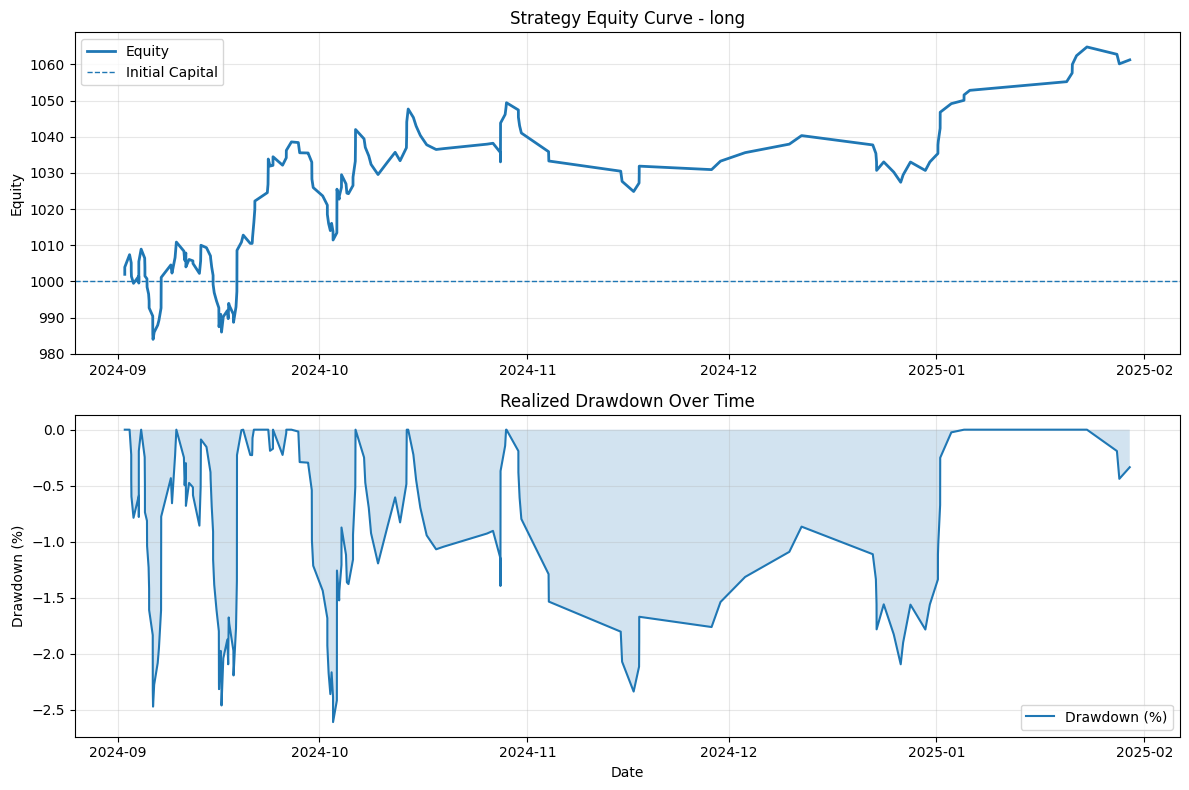


Running evaluation for: /home/danaee/bigdata_trader/long.json -> output: student_strategy_evaluation/long


STUDENT STRATEGY EVALUATION ON LONG
STUDENT STRATEGY SUMMARY
Direction: LONG
Rules    : 4
----------------------------------------------------------------------
RULE 1: TP=2.0179% | SL=1.9782% | Capital=12.5000% | Raw Matches=44
  1. [dmi_balance_14] IS Bearish
  2. [ret_vol_corr_30] IS Neutral Negative
  3. [vol_ratio_20_100] IS Very Low
  4. [return_skew_30] IS Strong Bearish
----------------------------------------------------------------------
RULE 2: TP=2.8339% | SL=2.3411% | Capital=7.5000% | Raw Matches=60
  1. [upside_semivol_20] IS Very High
  2. [macd_hist_atr] IS Neutral Negative
  3. [amihud_illiquidity_20] IS Very High
  4. [atr_ratio_14_63] IS Very High
  5. [return_skew_30] IS Extreme Bearish
----------------------------------------------------------------------
RULE 3: TP=2.5009% | SL=1.4546% | Capital=15.0000% | Raw Matches=60
  1. [amihud_illiquidity_20] IS Ver

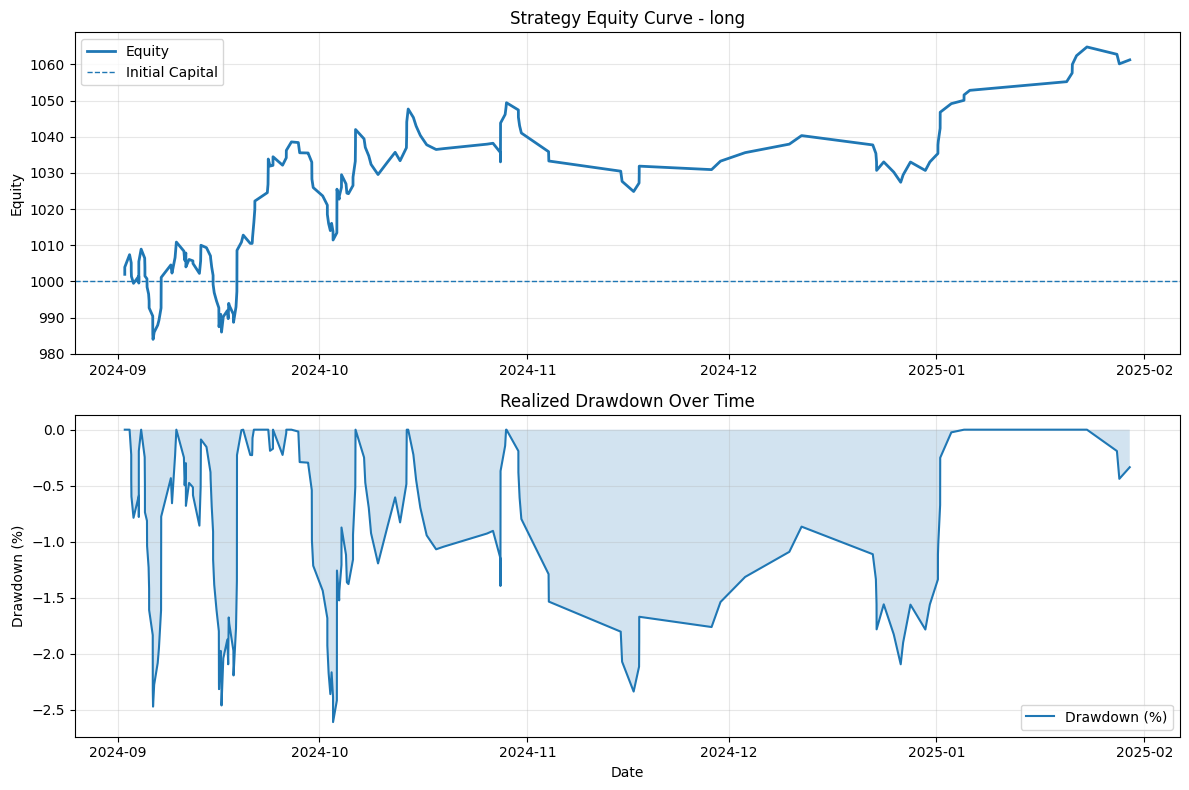


Running evaluation for: /home/danaee/bigdata_trader/short.json -> output: student_strategy_evaluation/short


STUDENT STRATEGY EVALUATION ON SHORT
STUDENT STRATEGY SUMMARY
Direction: SHORT
Rules    : 5
----------------------------------------------------------------------
RULE 1: TP=3.1960% | SL=1.6127% | Capital=15.0000% | Raw Matches=79
  1. [return_skew_30] IS Weak Bearish
  2. [rsi_hidden_div_flag] IS Positive (1)
  3. [drawdown_from_peak_60] IS Very High
  4. [dollar_vol_rel_20] IS Very Low
----------------------------------------------------------------------
RULE 2: TP=3.2994% | SL=1.7237% | Capital=10.0000% | Raw Matches=127
  1. [absret_ema_ratio_20_100] IS Medium
  2. [dmi_balance_14] IS Extreme Bearish
  3. [ret_autocorr_1_30] IS Weak Bullish
  4. [atr_pct_14] IS Medium
----------------------------------------------------------------------
RULE 3: TP=3.1331% | SL=1.4085% | Capital=10.0000% | Raw Matches=29
  1. [ema_slope_atr_20_5] IS Neutral Negative
  2. [rsi_hidden_div_f


Running evaluation for: /home/danaee/bigdata_trader/long.json -> output: student_strategy_evaluation/long


STUDENT STRATEGY EVALUATION ON LONG
STUDENT STRATEGY SUMMARY
Direction: LONG
Rules    : 4
----------------------------------------------------------------------
RULE 1: TP=2.0179% | SL=1.9782% | Capital=12.5000% | Raw Matches=44
  1. [dmi_balance_14] IS Bearish
  2. [ret_vol_corr_30] IS Neutral Negative
  3. [vol_ratio_20_100] IS Very Low
  4. [return_skew_30] IS Strong Bearish
----------------------------------------------------------------------
RULE 2: TP=2.8339% | SL=2.3411% | Capital=7.5000% | Raw Matches=60
  1. [upside_semivol_20] IS Very High
  2. [macd_hist_atr] IS Neutral Negative
  3. [amihud_illiquidity_20] IS Very High
  4. [atr_ratio_14_63] IS Very High
  5. [return_skew_30] IS Extreme Bearish
----------------------------------------------------------------------
RULE 3: TP=2.5009% | SL=1.4546% | Capital=15.0000% | Raw Matches=60
  1. [amihud_illiquidity_20] IS Ver

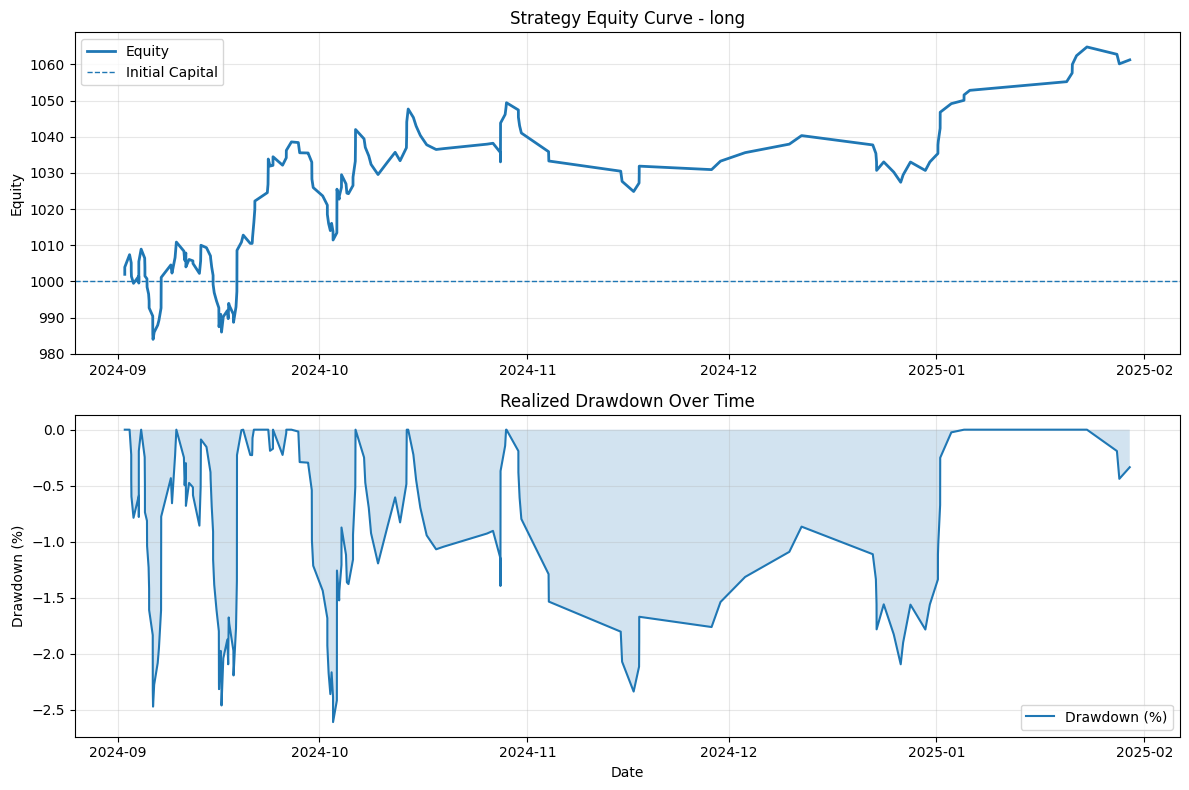


Running evaluation for: /home/danaee/bigdata_trader/short.json -> output: student_strategy_evaluation/short


STUDENT STRATEGY EVALUATION ON SHORT
STUDENT STRATEGY SUMMARY
Direction: SHORT
Rules    : 5
----------------------------------------------------------------------
RULE 1: TP=3.1960% | SL=1.6127% | Capital=15.0000% | Raw Matches=79
  1. [return_skew_30] IS Weak Bearish
  2. [rsi_hidden_div_flag] IS Positive (1)
  3. [drawdown_from_peak_60] IS Very High
  4. [dollar_vol_rel_20] IS Very Low
----------------------------------------------------------------------
RULE 2: TP=3.2994% | SL=1.7237% | Capital=10.0000% | Raw Matches=127
  1. [absret_ema_ratio_20_100] IS Medium
  2. [dmi_balance_14] IS Extreme Bearish
  3. [ret_autocorr_1_30] IS Weak Bullish
  4. [atr_pct_14] IS Medium
----------------------------------------------------------------------
RULE 3: TP=3.1331% | SL=1.4085% | Capital=10.0000% | Raw Matches=29
  1. [ema_slope_atr_20_5] IS Neutral Negative
  2. [rsi_hidden_div_f

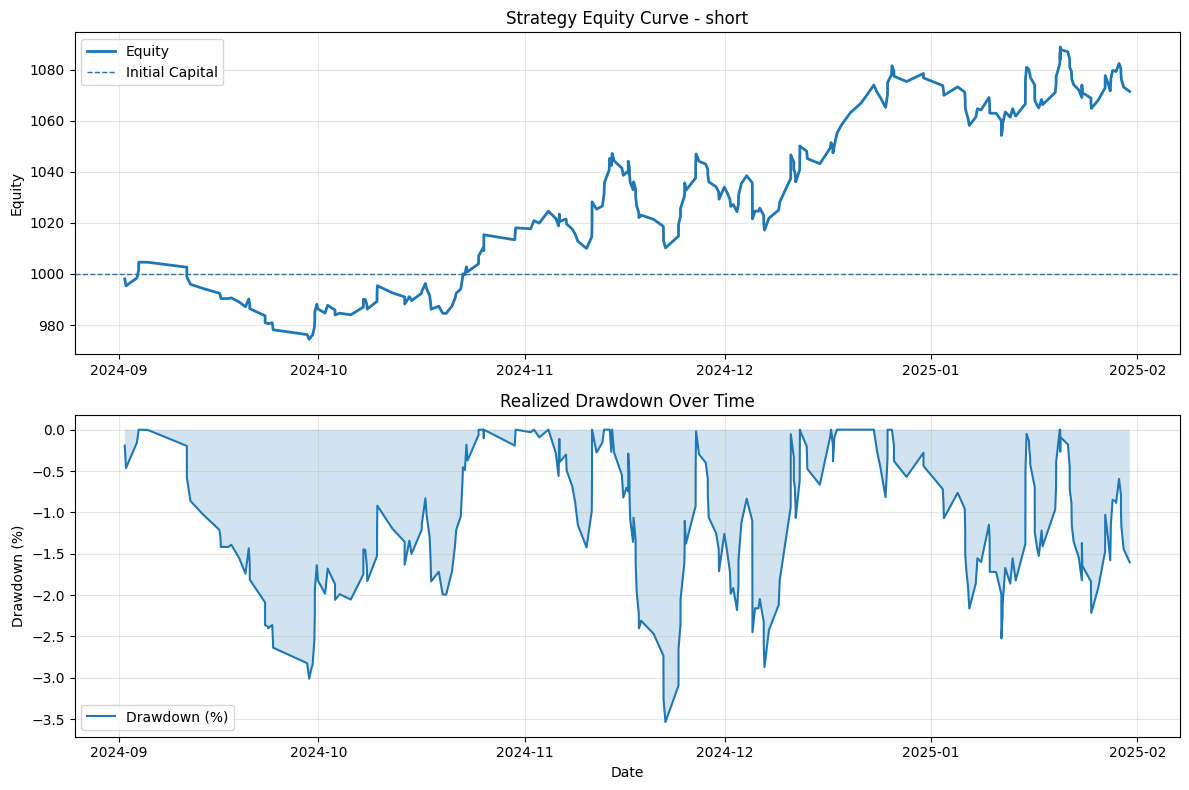

In [15]:
# =========================================================
# Student Strategy Input
# =========================================================
# Replace the example below with your own strategy.
# Keep the same format:
#   - direction: "long" or "short"
#   - capital_pct: required at strategy level or inside every rule
#   - rules_set: list of rules
#   - each rule must have tp, sl, and conditions
#   - rule-level capital_pct overrides strategy-level capital_pct
#   - each condition must be written exactly as: "[feature_name] IS Value Name"

student_strategy = {
  "direction": "long",
  "rules_set": [
    {
      "tp": 4.39,
      "sl": 1.26,
      "capital_pct": 25.0,
      "conditions": [
        "[body_to_tr] IS Very High",
        "[vol_of_vol_ratio_20] IS Medium"
      ]
    },
    {
      "tp": 4.26,
      "sl": 8.54,
      "capital_pct": 10.0,
      "conditions": [
        "[ret_autocorr_1_30] IS Extreme Bullish",
        "[ret_vol_corr_30] IS Extreme Bullish",
        "[vol_of_vol_ratio_20] IS Very High"
      ]
    },
    {
      "tp": 8.76,
      "sl": 3.4,
      "capital_pct": 20.0,
      "conditions": [
        "[macd_hist_atr] IS Strong Bullish",
        "[ret_vol_corr_30] IS Extreme Bullish",
        "[up_close_ratio_5] IS Medium"
      ]
    }
  ]
}




# IMPORTANT:
# The example condition above is a placeholder.
# Before running the evaluation cell, replace it with your real strategy conditions.


<div dir="rtl" style="text-align: center;">

## اجرای ارزیابی Train و Test
<div>
<div dir="rtl" style="text-align: right;">

قبل از اجرای سلول بعدی، strategy نمونه را با strategy واقعی جایگزین کنید.

این بخش strategy را ابتدا روی `REFERENCE_SCHEMA_PATH` که معمولاً همان train است اجرا می‌کند، سپس روی `EVALUATION_FILE_PATH` که معمولاً test است اجرا می‌کند. خروجی‌های train و test در دو پوشه جدا ذخیره می‌شوند.
<div>

Loading reference schema data...
Data Loaded and Cleaned: 701520 valid rows | Features: 52
Reference/train source: data/train.csv
Train data ready: 701520 rows | Features: 52
Evaluation/test data loaded: 437760 rows | Features: 52

STUDENT STRATEGY EVALUATION ON TRAIN/REFERENCE DATASET
STUDENT STRATEGY SUMMARY
Direction: LONG
Rules    : 3
----------------------------------------------------------------------
RULE 1: TP=4.3900% | SL=1.2600% | Capital=25.0000% | Raw Matches=30476
  1. [body_to_tr] IS Very High
  2. [vol_of_vol_ratio_20] IS Medium
----------------------------------------------------------------------
RULE 2: TP=4.2600% | SL=8.5400% | Capital=10.0000% | Raw Matches=25902
  1. [ret_autocorr_1_30] IS Extreme Bullish
  2. [ret_vol_corr_30] IS Extreme Bullish
  3. [vol_of_vol_ratio_20] IS Very High
----------------------------------------------------------------------
RULE 3: TP=8.7600% | SL=3.4000% | Capital=20.0000% | Raw Matches=1694
  1. [macd_hist_atr] IS Strong Bullish
 

Loading reference schema data...
Data Loaded and Cleaned: 701520 valid rows | Features: 52
Reference/train source: data/train.csv
Train data ready: 701520 rows | Features: 52
Evaluation/test data loaded: 437760 rows | Features: 52

STUDENT STRATEGY EVALUATION ON TRAIN/REFERENCE DATASET
STUDENT STRATEGY SUMMARY
Direction: LONG
Rules    : 3
----------------------------------------------------------------------
RULE 1: TP=4.3900% | SL=1.2600% | Capital=25.0000% | Raw Matches=30476
  1. [body_to_tr] IS Very High
  2. [vol_of_vol_ratio_20] IS Medium
----------------------------------------------------------------------
RULE 2: TP=4.2600% | SL=8.5400% | Capital=10.0000% | Raw Matches=25902
  1. [ret_autocorr_1_30] IS Extreme Bullish
  2. [ret_vol_corr_30] IS Extreme Bullish
  3. [vol_of_vol_ratio_20] IS Very High
----------------------------------------------------------------------
RULE 3: TP=8.7600% | SL=3.4000% | Capital=20.0000% | Raw Matches=1694
  1. [macd_hist_atr] IS Strong Bullish
 

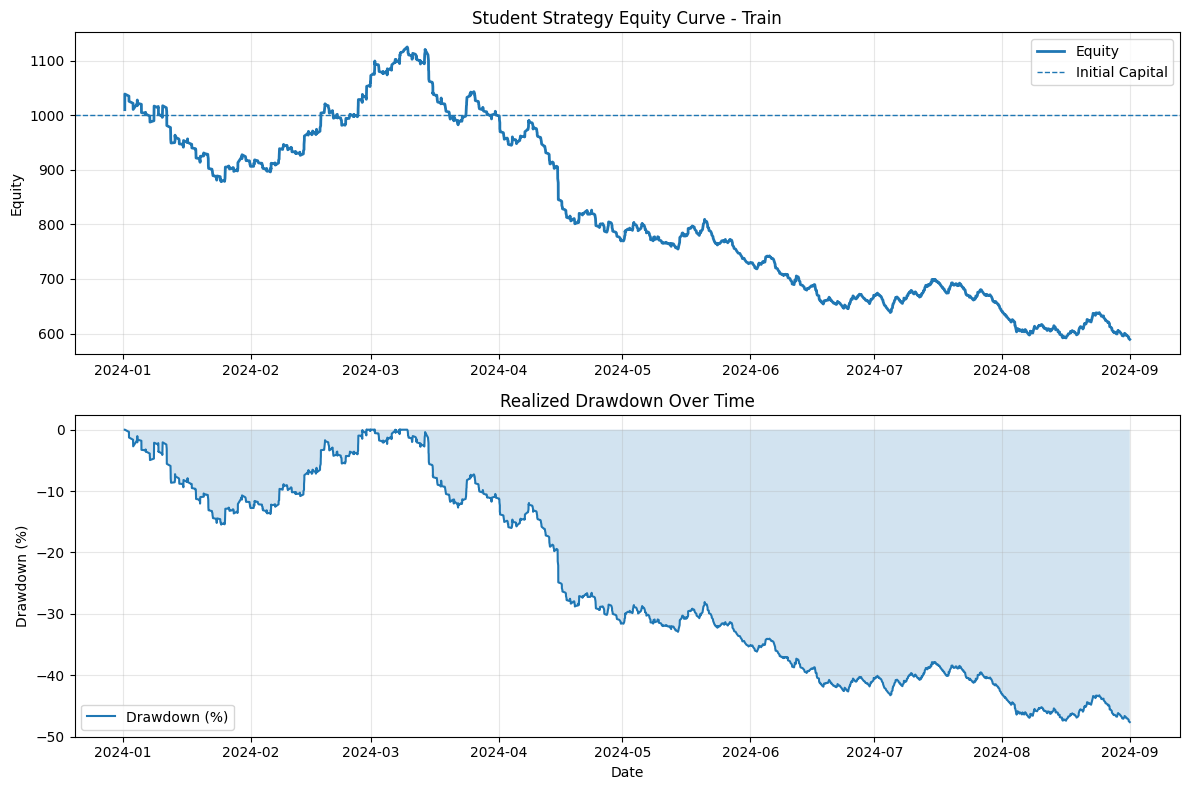

Loading reference schema data...
Data Loaded and Cleaned: 701520 valid rows | Features: 52
Reference/train source: data/train.csv
Train data ready: 701520 rows | Features: 52
Evaluation/test data loaded: 437760 rows | Features: 52

STUDENT STRATEGY EVALUATION ON TRAIN/REFERENCE DATASET
STUDENT STRATEGY SUMMARY
Direction: LONG
Rules    : 3
----------------------------------------------------------------------
RULE 1: TP=4.3900% | SL=1.2600% | Capital=25.0000% | Raw Matches=30476
  1. [body_to_tr] IS Very High
  2. [vol_of_vol_ratio_20] IS Medium
----------------------------------------------------------------------
RULE 2: TP=4.2600% | SL=8.5400% | Capital=10.0000% | Raw Matches=25902
  1. [ret_autocorr_1_30] IS Extreme Bullish
  2. [ret_vol_corr_30] IS Extreme Bullish
  3. [vol_of_vol_ratio_20] IS Very High
----------------------------------------------------------------------
RULE 3: TP=8.7600% | SL=3.4000% | Capital=20.0000% | Raw Matches=1694
  1. [macd_hist_atr] IS Strong Bullish
 

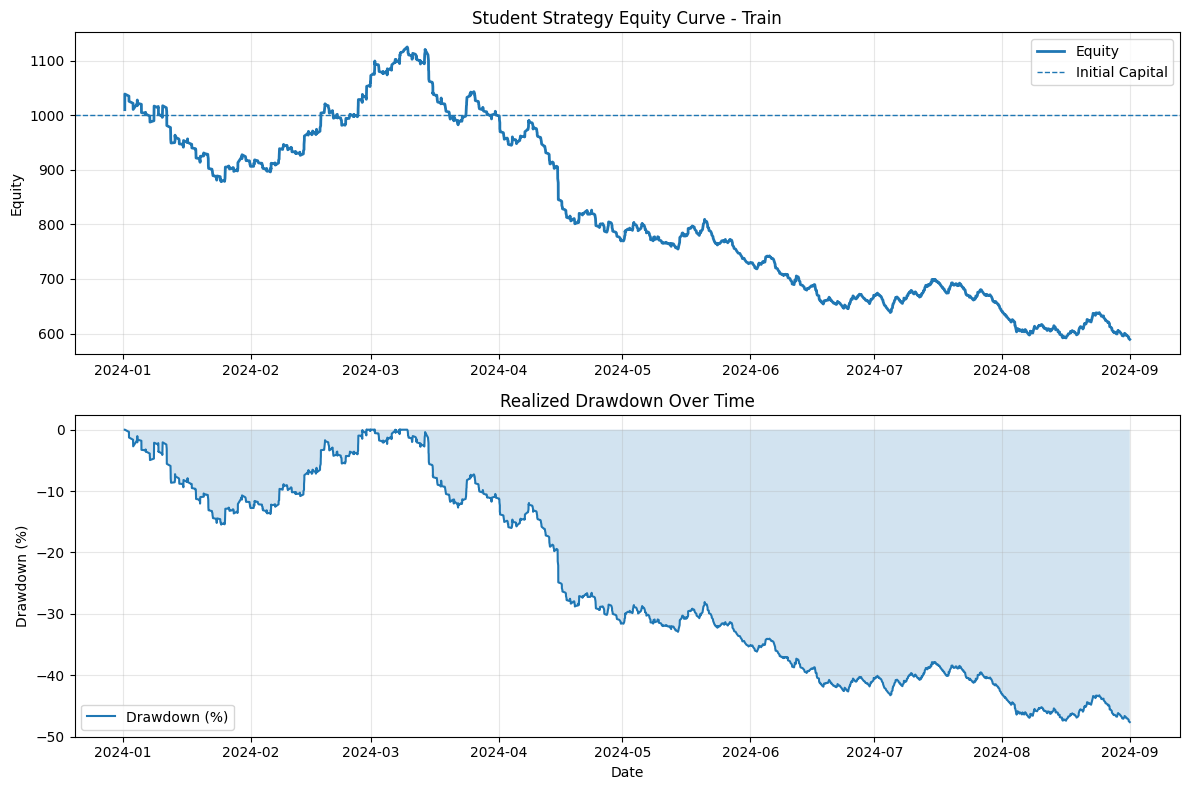

Saved summary to: student_strategy_evaluation/train/student_strategy_summary.json
Saved trade logs to: student_strategy_evaluation/train/student_strategy_trade_logs.csv

STUDENT STRATEGY EVALUATION ON TEST/EVALUATION DATASET
STUDENT STRATEGY SUMMARY
Direction: LONG
Rules    : 3
----------------------------------------------------------------------
RULE 1: TP=4.3900% | SL=1.2600% | Capital=25.0000% | Raw Matches=16589
  1. [body_to_tr] IS Very High
  2. [vol_of_vol_ratio_20] IS Medium
----------------------------------------------------------------------
RULE 2: TP=4.2600% | SL=8.5400% | Capital=10.0000% | Raw Matches=11734
  1. [ret_autocorr_1_30] IS Extreme Bullish
  2. [ret_vol_corr_30] IS Extreme Bullish
  3. [vol_of_vol_ratio_20] IS Very High
----------------------------------------------------------------------
RULE 3: TP=8.7600% | SL=3.4000% | Capital=20.0000% | Raw Matches=1033
  1. [macd_hist_atr] IS Strong Bullish
  2. [ret_vol_corr_30] IS Extreme Bullish
  3. [up_close_ratio_

Loading reference schema data...
Data Loaded and Cleaned: 701520 valid rows | Features: 52
Reference/train source: data/train.csv
Train data ready: 701520 rows | Features: 52
Evaluation/test data loaded: 437760 rows | Features: 52

STUDENT STRATEGY EVALUATION ON TRAIN/REFERENCE DATASET
STUDENT STRATEGY SUMMARY
Direction: LONG
Rules    : 3
----------------------------------------------------------------------
RULE 1: TP=4.3900% | SL=1.2600% | Capital=25.0000% | Raw Matches=30476
  1. [body_to_tr] IS Very High
  2. [vol_of_vol_ratio_20] IS Medium
----------------------------------------------------------------------
RULE 2: TP=4.2600% | SL=8.5400% | Capital=10.0000% | Raw Matches=25902
  1. [ret_autocorr_1_30] IS Extreme Bullish
  2. [ret_vol_corr_30] IS Extreme Bullish
  3. [vol_of_vol_ratio_20] IS Very High
----------------------------------------------------------------------
RULE 3: TP=8.7600% | SL=3.4000% | Capital=20.0000% | Raw Matches=1694
  1. [macd_hist_atr] IS Strong Bullish
 

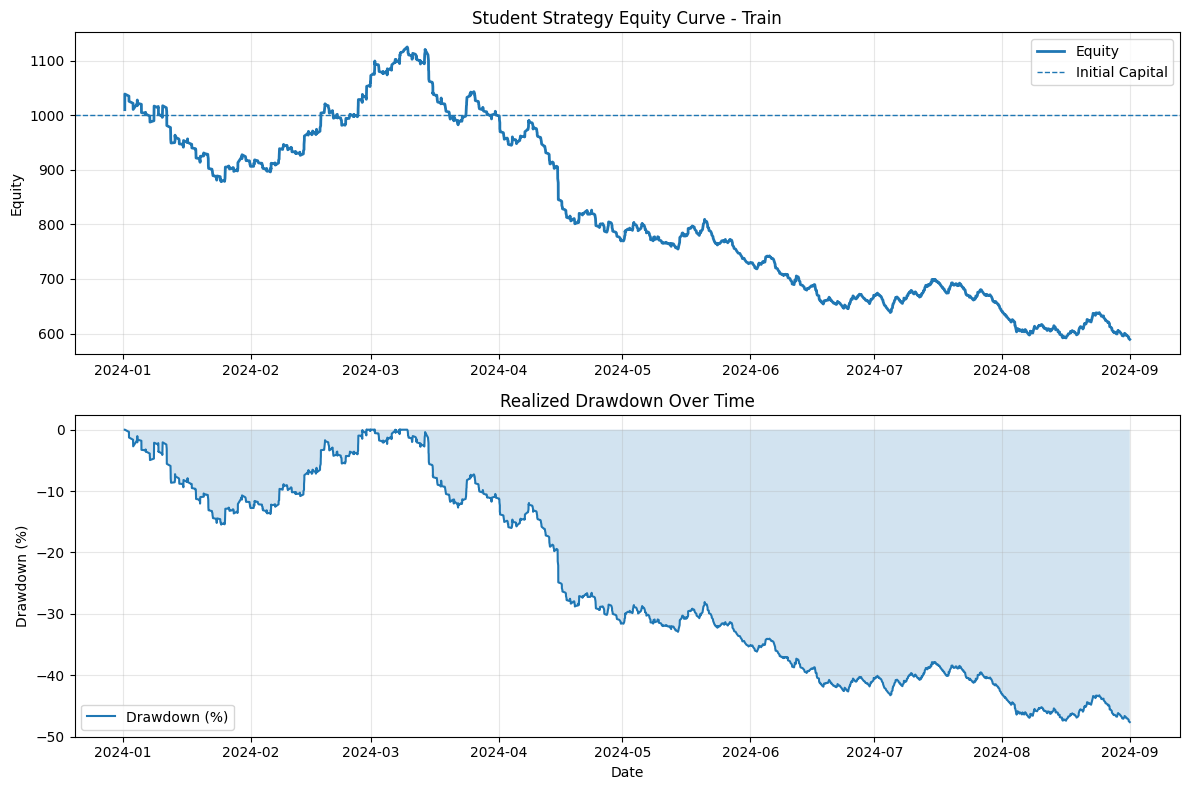

Saved summary to: student_strategy_evaluation/train/student_strategy_summary.json
Saved trade logs to: student_strategy_evaluation/train/student_strategy_trade_logs.csv

STUDENT STRATEGY EVALUATION ON TEST/EVALUATION DATASET
STUDENT STRATEGY SUMMARY
Direction: LONG
Rules    : 3
----------------------------------------------------------------------
RULE 1: TP=4.3900% | SL=1.2600% | Capital=25.0000% | Raw Matches=16589
  1. [body_to_tr] IS Very High
  2. [vol_of_vol_ratio_20] IS Medium
----------------------------------------------------------------------
RULE 2: TP=4.2600% | SL=8.5400% | Capital=10.0000% | Raw Matches=11734
  1. [ret_autocorr_1_30] IS Extreme Bullish
  2. [ret_vol_corr_30] IS Extreme Bullish
  3. [vol_of_vol_ratio_20] IS Very High
----------------------------------------------------------------------
RULE 3: TP=8.7600% | SL=3.4000% | Capital=20.0000% | Raw Matches=1033
  1. [macd_hist_atr] IS Strong Bullish
  2. [ret_vol_corr_30] IS Extreme Bullish
  3. [up_close_ratio_

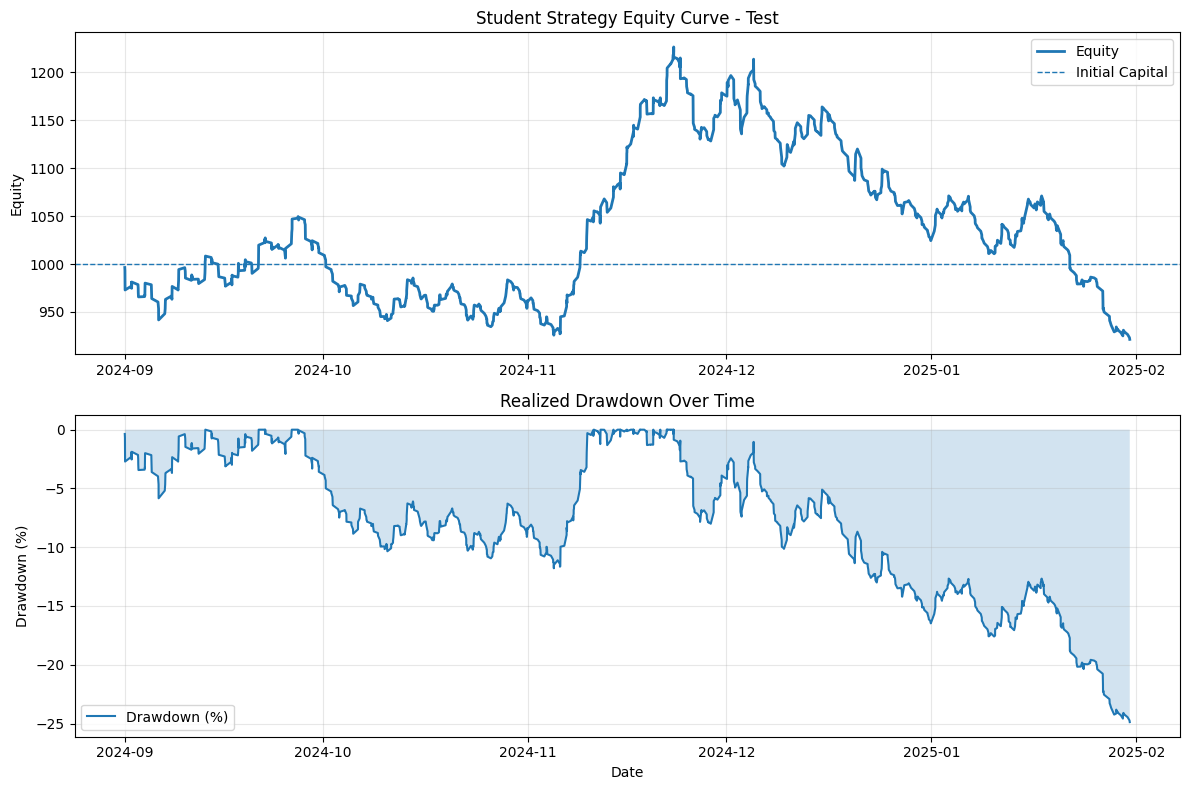

Loading reference schema data...
Data Loaded and Cleaned: 701520 valid rows | Features: 52
Reference/train source: data/train.csv
Train data ready: 701520 rows | Features: 52
Evaluation/test data loaded: 437760 rows | Features: 52

STUDENT STRATEGY EVALUATION ON TRAIN/REFERENCE DATASET
STUDENT STRATEGY SUMMARY
Direction: LONG
Rules    : 3
----------------------------------------------------------------------
RULE 1: TP=4.3900% | SL=1.2600% | Capital=25.0000% | Raw Matches=30476
  1. [body_to_tr] IS Very High
  2. [vol_of_vol_ratio_20] IS Medium
----------------------------------------------------------------------
RULE 2: TP=4.2600% | SL=8.5400% | Capital=10.0000% | Raw Matches=25902
  1. [ret_autocorr_1_30] IS Extreme Bullish
  2. [ret_vol_corr_30] IS Extreme Bullish
  3. [vol_of_vol_ratio_20] IS Very High
----------------------------------------------------------------------
RULE 3: TP=8.7600% | SL=3.4000% | Capital=20.0000% | Raw Matches=1694
  1. [macd_hist_atr] IS Strong Bullish
 

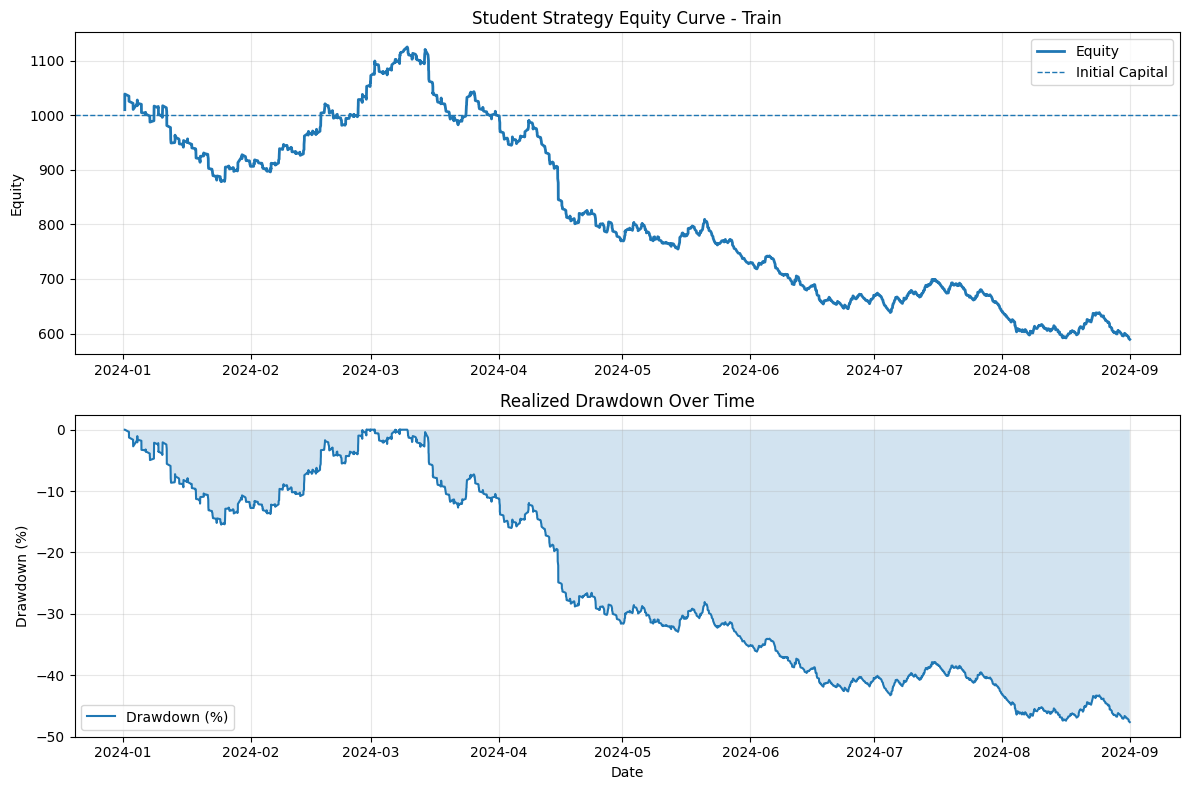

Saved summary to: student_strategy_evaluation/train/student_strategy_summary.json
Saved trade logs to: student_strategy_evaluation/train/student_strategy_trade_logs.csv

STUDENT STRATEGY EVALUATION ON TEST/EVALUATION DATASET
STUDENT STRATEGY SUMMARY
Direction: LONG
Rules    : 3
----------------------------------------------------------------------
RULE 1: TP=4.3900% | SL=1.2600% | Capital=25.0000% | Raw Matches=16589
  1. [body_to_tr] IS Very High
  2. [vol_of_vol_ratio_20] IS Medium
----------------------------------------------------------------------
RULE 2: TP=4.2600% | SL=8.5400% | Capital=10.0000% | Raw Matches=11734
  1. [ret_autocorr_1_30] IS Extreme Bullish
  2. [ret_vol_corr_30] IS Extreme Bullish
  3. [vol_of_vol_ratio_20] IS Very High
----------------------------------------------------------------------
RULE 3: TP=8.7600% | SL=3.4000% | Capital=20.0000% | Raw Matches=1033
  1. [macd_hist_atr] IS Strong Bullish
  2. [ret_vol_corr_30] IS Extreme Bullish
  3. [up_close_ratio_

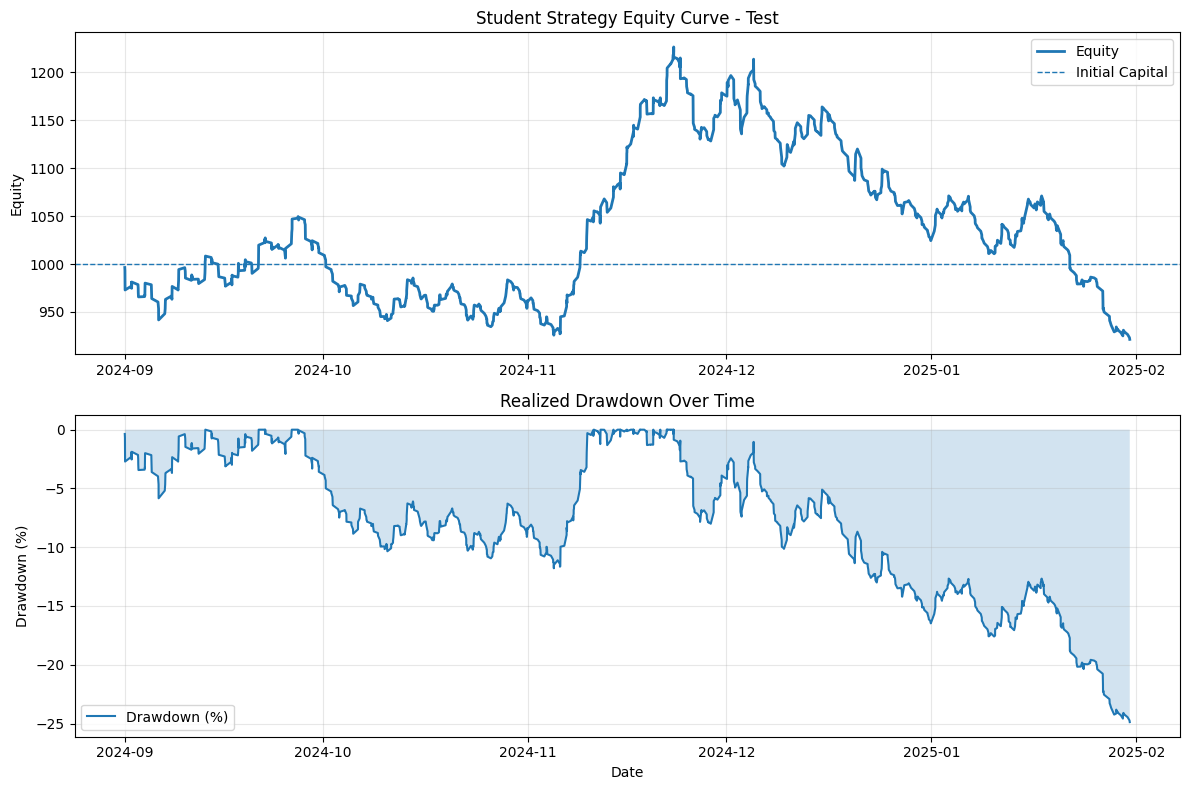

Saved summary to: student_strategy_evaluation/test/student_strategy_summary.json
Saved trade logs to: student_strategy_evaluation/test/student_strategy_trade_logs.csv

TRAIN VS TEST PERFORMANCE COMPARISON
Final Equity             | Train:       589.24 | Test:       921.34
Account Return (%)       | Train:       -41.08 | Test:        -7.87
Max Drawdown (%)         | Train:        47.64 | Test:        24.88
Win Rate (%)             | Train:        36.00 | Test:        38.43
Profit Factor            | Train:         0.81 | Test:         0.95
Raw Signals              | Train:        57822 | Test:        29230
Executed Trades          | Train:         2164 | Test:         1210
Skipped Below Minimum    | Train:        55658 | Test:        28020
Max Open Positions       | Train:           17 | Test:           13
Max Open Exposure        | Train:      1125.45 | Test:      1224.64
Status                   | Train:     SURVIVED | Test:     SURVIVED

Interpretation note:
- Train performance shows

In [13]:
# =========================================================
# Run Train and Test Evaluation
# =========================================================

df_train, df_eval, feature_cols, feature_modes, label_cols = load_training_and_evaluation_data(
    reference_schema_path=REFERENCE_SCHEMA_PATH,
    evaluation_file_path=EVALUATION_FILE_PATH,
)

# ---------------------------------------------------------
# 1) Train / Reference Dataset Performance
# ---------------------------------------------------------
train_metrics, train_trade_logs, train_internal_strategy = evaluate_student_strategy_on_dataset(
    df_eval=df_train,
    feature_cols=feature_cols,
    feature_modes=feature_modes,
    student_strategy=student_strategy,
    dataset_name="train/reference dataset",
    return_logs=True,
)

plot_equity_curve(train_trade_logs, title="Student Strategy Equity Curve - Train")

save_student_evaluation_outputs(
    metrics=train_metrics,
    trade_logs=train_trade_logs,
    student_strategy=student_strategy,
    output_dir=os.path.join(EVALUATION_OUTPUT_DIR, "train"),
)

# ---------------------------------------------------------
# 2) Test / Evaluation Dataset Performance
# ---------------------------------------------------------
test_metrics, test_trade_logs, test_internal_strategy = evaluate_student_strategy_on_dataset(
    df_eval=df_eval,
    feature_cols=feature_cols,
    feature_modes=feature_modes,
    student_strategy=student_strategy,
    dataset_name="test/evaluation dataset",
    return_logs=True,
)

plot_equity_curve(test_trade_logs, title="Student Strategy Equity Curve - Test")

save_student_evaluation_outputs(
    metrics=test_metrics,
    trade_logs=test_trade_logs,
    student_strategy=student_strategy,
    output_dir=os.path.join(EVALUATION_OUTPUT_DIR, "test"),
)

# ---------------------------------------------------------
# 3) Compact Train vs Test Comparison
# ---------------------------------------------------------
print_train_test_comparison(train_metrics, test_metrics)



<div dir="rtl" style="text-align: center;">

## نکات مهم برای دانشجویان

<div>


<div dir="rtl" style="text-align: right;">

این نوت‌بوک فقط evaluator است و هیچ optimization یا genetic algorithm اجرا نمی‌کند. استراتژی باید در سلول `Student Strategy Input` وارد شود.

این نسخه strategy را روی دو dataset اجرا می‌کند:

- `REFERENCE_SCHEMA_PATH`: معمولاً همان train است و برای ساخت schema و گزارش عملکرد train استفاده می‌شود.
- `EVALUATION_FILE_PATH`: معمولاً همان test است و نتیجه out-of-sample را نشان می‌دهد.

فرمت شرط‌ها باید دقیقاً مشابه خروجی strategy باشد، مثل:

```python
"[open_gap_atr_14] IS Neutral Positive"
```

نتیجه test مهم‌تر از train است. اگر عملکرد train خیلی خوب و عملکرد test ضعیف باشد، احتمال overfitting یا حساسیت strategy به regime بازار وجود دارد.

نکات محدودیت شبیه‌سازی:

- کارمزد `FEE_PCT` به‌صورت round-trip است.
- سایز هر معامله برابر `capital_pct` درصد از equity فعلی است؛ این مقدار باید داخل strategy یا داخل هر rule وارد شود و دیگر ثابت evaluator نیست. `SL` فقط برای خروج معامله استفاده می‌شود و سایز معامله را محدود نمی‌کند.
- چون دیتاست `exit_bar_index` ندارد، exposure تا `MAX_HOLD_CANDLES` رزرو می‌شود.
- اگر مقدار دلاری معامله بعد از اعمال محدودیت سرمایه کمتر از `MIN_POSITION_NOTIONAL` باشد، آن سیگنال معامله نمی‌شود.
- drawdown گزارش‌شده realized drawdown است، نه intra-trade mark-to-market drawdown.
- این evaluator مدل کامل صرافی، slippage، funding، liquidation و partial fill را شبیه‌سازی نمی‌کند.
<div>